# Volume experiment — b-approximated polytope ratio

For each quantization bit-width $b$, plots:
$$\frac{\sum_{i} W^b_i}{\sum_{i} W^{\mathrm{correct}}_i}$$
where the sums run over all samples $i$ in the result files.
A ratio close to 1 means the quantized model preserves almost all the volume of the correct polytope.

## Setup

In [109]:
%load_ext autoreload
%autoreload 2

import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Load results

In [110]:
RESULTS_DIR = ROOT / "results" / "volumes_mlp"  # change to "volumes" for the full run

def load_records(results_dir):
    recs = []
    for f in sorted(Path(results_dir).glob("volumes_sample*.json")):
        with open(f) as fh:
            recs.append(json.load(fh))
    return recs

records = load_records(RESULTS_DIR)
print(f"Found {len(records)} result files.")

bits_grid = sorted(int(b) for b in records[0]["widths_both"].keys())
print("Bits grid:", bits_grid)

Found 4000 result files.
Bits grid: [4, 6, 8, 10, 12, 16]


## Fix NaN volumes

NaNs arise when the b-approximated polytope is empty (quantized model predicts a
different class than the full-precision model on $x_0$).
- `width_correct` is recomputed independently and should be a valid positive number.
- `widths_both[b]` is recomputed per bit-width; if still infeasible → set to 0
  (empty polytope = zero volume = error 1).

In [111]:
from src.optim.fix_nan_volumes import fix_nan_volumes

def get_nan_indices(records):
    return sorted(r["sample_idx"] for r in records if math.isnan(r["width_correct"]))

# --- Before fix ---
nan_before = get_nan_indices(records)
print(f"NaN sample indices BEFORE fix ({len(nan_before)} total):")
print(nan_before)

# --- Run fix ---
print("\nRunning fix_nan_volumes...")
modified_indices = fix_nan_volumes(
    results_dir  = RESULTS_DIR,
    model_path   = ROOT / "checkpoints" / "fashion_mlp_best.pth",
    data_path    = ROOT / "data" / "fashionMNIST_correct_mlp.pt",
    n_directions = 200,
    verbose      = True,
)

# --- After fix ---
records = load_records(RESULTS_DIR)
nan_after = get_nan_indices(records)
print(f"\nNaN sample indices AFTER fix ({len(nan_after)} total):")
print(nan_after if nan_after else "None — all NaNs resolved.")

NaN sample indices BEFORE fix (0 total):
[]

Running fix_nan_volumes...
Found 0 NaN files out of 4000 total.

NaN sample indices AFTER fix (0 total):
None — all NaNs resolved.


## Compute per-bits ratio

$$\text{ratio}(b) = \frac{\sum_{i} W^b_i}{\sum_{i} W^{\mathrm{correct}}_i}$$

Any remaining NaN (e.g. empty polytope not fixed) is treated as 0.

In [112]:
def safe_width(r, b):
    v = r["widths_both"][str(b)]
    return 0.0 if math.isnan(v) else v

def safe_correct(r):
    v = r["width_correct"]
    return 0.0 if math.isnan(v) else v

sum_correct = sum(safe_correct(r) for r in records)
ratios = {
    b: sum(safe_width(r, b) for r in records) / sum_correct
    for b in bits_grid
}
ratios[32] = 1.0

print(f"Records: {len(records)}  |  sum_correct: {sum_correct:.2f}")
print("\nRatios:")
for b, ratio in ratios.items():
    print(f"  bits={b:2d}  ratio={ratio:.6f}  error={1-ratio:.6f}")

Records: 4000  |  sum_correct: 159226.16

Ratios:
  bits= 4  ratio=0.939593  error=0.060407
  bits= 6  ratio=0.985456  error=0.014544
  bits= 8  ratio=0.996381  error=0.003619
  bits=10  ratio=0.999088  error=0.000912
  bits=12  ratio=0.999788  error=0.000212
  bits=16  ratio=0.999987  error=0.000013
  bits=32  ratio=1.000000  error=0.000000


## Plot

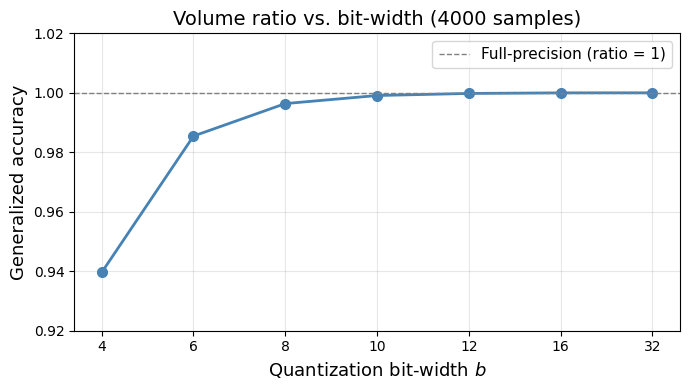

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/volumes_mlp/volumes_ratio.pdf


In [113]:
bits_arr  = list(np.array(bits_grid)) + [32]  # add 32-bit reference
ratio_arr = np.array([ratios[b] for b in bits_arr])

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(range(len(bits_arr)), ratio_arr, marker="o", linewidth=2, markersize=7, color="steelblue")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Full-precision (ratio = 1)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Generalized accuracy", fontsize=13)
ax.set_title(f"Volume ratio vs. bit-width ({len(records)} samples)", fontsize=14)
ax.set_xticks(range(len(bits_arr)))
ax.set_xticklabels(bits_arr)
ax.set_ylim(0.92, 1.02)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "volumes_ratio.pdf", bbox_inches="tight")
plt.show()
print("Saved to", RESULTS_DIR / "volumes_ratio.pdf")